# Análisis de Sincronización: Hilbert + Kuramoto + Joint Recurrence Plots (T11/T12) - Output

Results of the synchronization analysis between T11 and T12.

The T11 and T12 signals already exhibit a natural (physical) time delay between them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Publication-quality figure settings
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.linewidth': 0.8,
    'xtick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.size': 4,
    'ytick.major.width': 0.8,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': 'black',
    'lines.linewidth': 1.0,
    'lines.markersize': 4
})
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Load saved results
results_df = pd.read_parquet('../data/kuramoto_jrp_lag_sweep_T11_T12.parquet')
print(f'Loaded {len(results_df)} lag points')
print(results_df.head())

# Calculate real lag from data (need to load original data for this)
import sys
sys.path.insert(0, '../src')
from synch_analysis import DataSource
# We'll use the real_lag value from the analysis (90s) - alternatively recompute
real_lag = 90  # seconds (1.5 min)

Loaded 201 lag points
   lag    r_mean     r_std  frac_above_07  max_sustained_sec    jrp_RR  \
0 -500  0.571144  0.305622       0.405338                 20  0.095694   
1 -495  0.570027  0.302437       0.394495                 20  0.094584   
2 -490  0.580246  0.300974       0.411176                 20  0.096374   
3 -485  0.584064  0.301746       0.422018                 20  0.096271   
4 -480  0.588812  0.306773       0.432861                 20  0.093922   

    jrp_DET   jrp_LAM  jrp_max_diag  kuramoto_score  jrp_score  combined_score  
0  0.971944  0.984384          1195        0.000107   0.000000        0.000053  
1  0.968757  0.982342          1195        0.000000   0.147454        0.073727  
2  0.970427  0.983426          1195        0.001503   0.200929        0.101216  
3  0.972199  0.984550          1195        0.003406   0.197833        0.100619  
4  0.972070  0.984380          1195        0.006354   0.127662        0.067008  


In [2]:
# Summary statistics
best_kuramoto = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])
best_kuramoto_sustained = results_df.loc[results_df['kuramoto_score'].idxmax(), 'max_sustained_sec']
best_kuramoto_frac = results_df.loc[results_df['kuramoto_score'].idxmax(), 'frac_above_07']
best_kuramoto_r = results_df.loc[results_df['kuramoto_score'].idxmax(), 'r_mean']

real_lag = 90  # seconds

jrp_valid = results_df[(results_df['lag'] != -results_df['lag'].max()) & (results_df['lag'] != results_df['lag'].max()) & (results_df['jrp_RR'] > 0)].copy()

# JRP score: Recurrence Rate (RR) as sole criterion
def normalize(series):
    min_v, max_v = series.min(), series.max()
    if max_v > min_v:
        return (series - min_v) / (max_v - min_v)
    return series * 0

jrp_valid['jrp_RR_norm'] = normalize(jrp_valid['jrp_RR'])
best_jrp = int(jrp_valid.loc[jrp_valid['jrp_RR_norm'].idxmax(), 'lag']) if len(jrp_valid) > 0 else 'N/A'
best_combined = int(results_df.loc[results_df['combined_score'].idxmax(), 'lag'])

print('=== FINAL SUMMARY ===')
print(f'Real lag (distance/speed):                          {real_lag}s ({real_lag/60:.1f} min)')
print(f'Best lag (Kuramoto - frac_above_07 × r_mean):     {best_kuramoto}s ({best_kuramoto/60:.1f} min)  [max_sustained={best_kuramoto_sustained:.0f}s, frac_above_07={best_kuramoto_frac:.3f}, r_mean={best_kuramoto_r:.3f}]')
print(f'Best lag (JRP - RR only, excl. extreme lags):    {best_jrp}s ({best_jrp/60:.1f} min)')
print(f'Best lag (Combined):                               {best_combined}s ({best_combined/60:.1f} min)')

error_kuramoto = abs(best_kuramoto - real_lag)
error_jrp = abs(best_jrp - real_lag) if best_jrp != 'N/A' else 'N/A'
error_combined = abs(best_combined - real_lag)
print(f'\nErrors vs real lag:')
print(f'  Kuramoto:  {error_kuramoto}s')
print(f'  JRP (RR):  {error_jrp}s' if error_jrp != 'N/A' else '  JRP (RR):       N/A')
print(f'  Combined:  {error_combined}s')

=== FINAL SUMMARY ===
Real lag (distance/speed):                          90s (1.5 min)
Best lag (Kuramoto - frac_above_07 × r_mean):     90s (1.5 min)  [max_sustained=74s, frac_above_07=0.816, r_mean=0.838]
Best lag (JRP - RR only, excl. extreme lags):    90s (1.5 min)
Best lag (Combined):                               90s (1.5 min)

Errors vs real lag:
  Kuramoto:  0s
  JRP (RR):  0s
  Combined:  0s


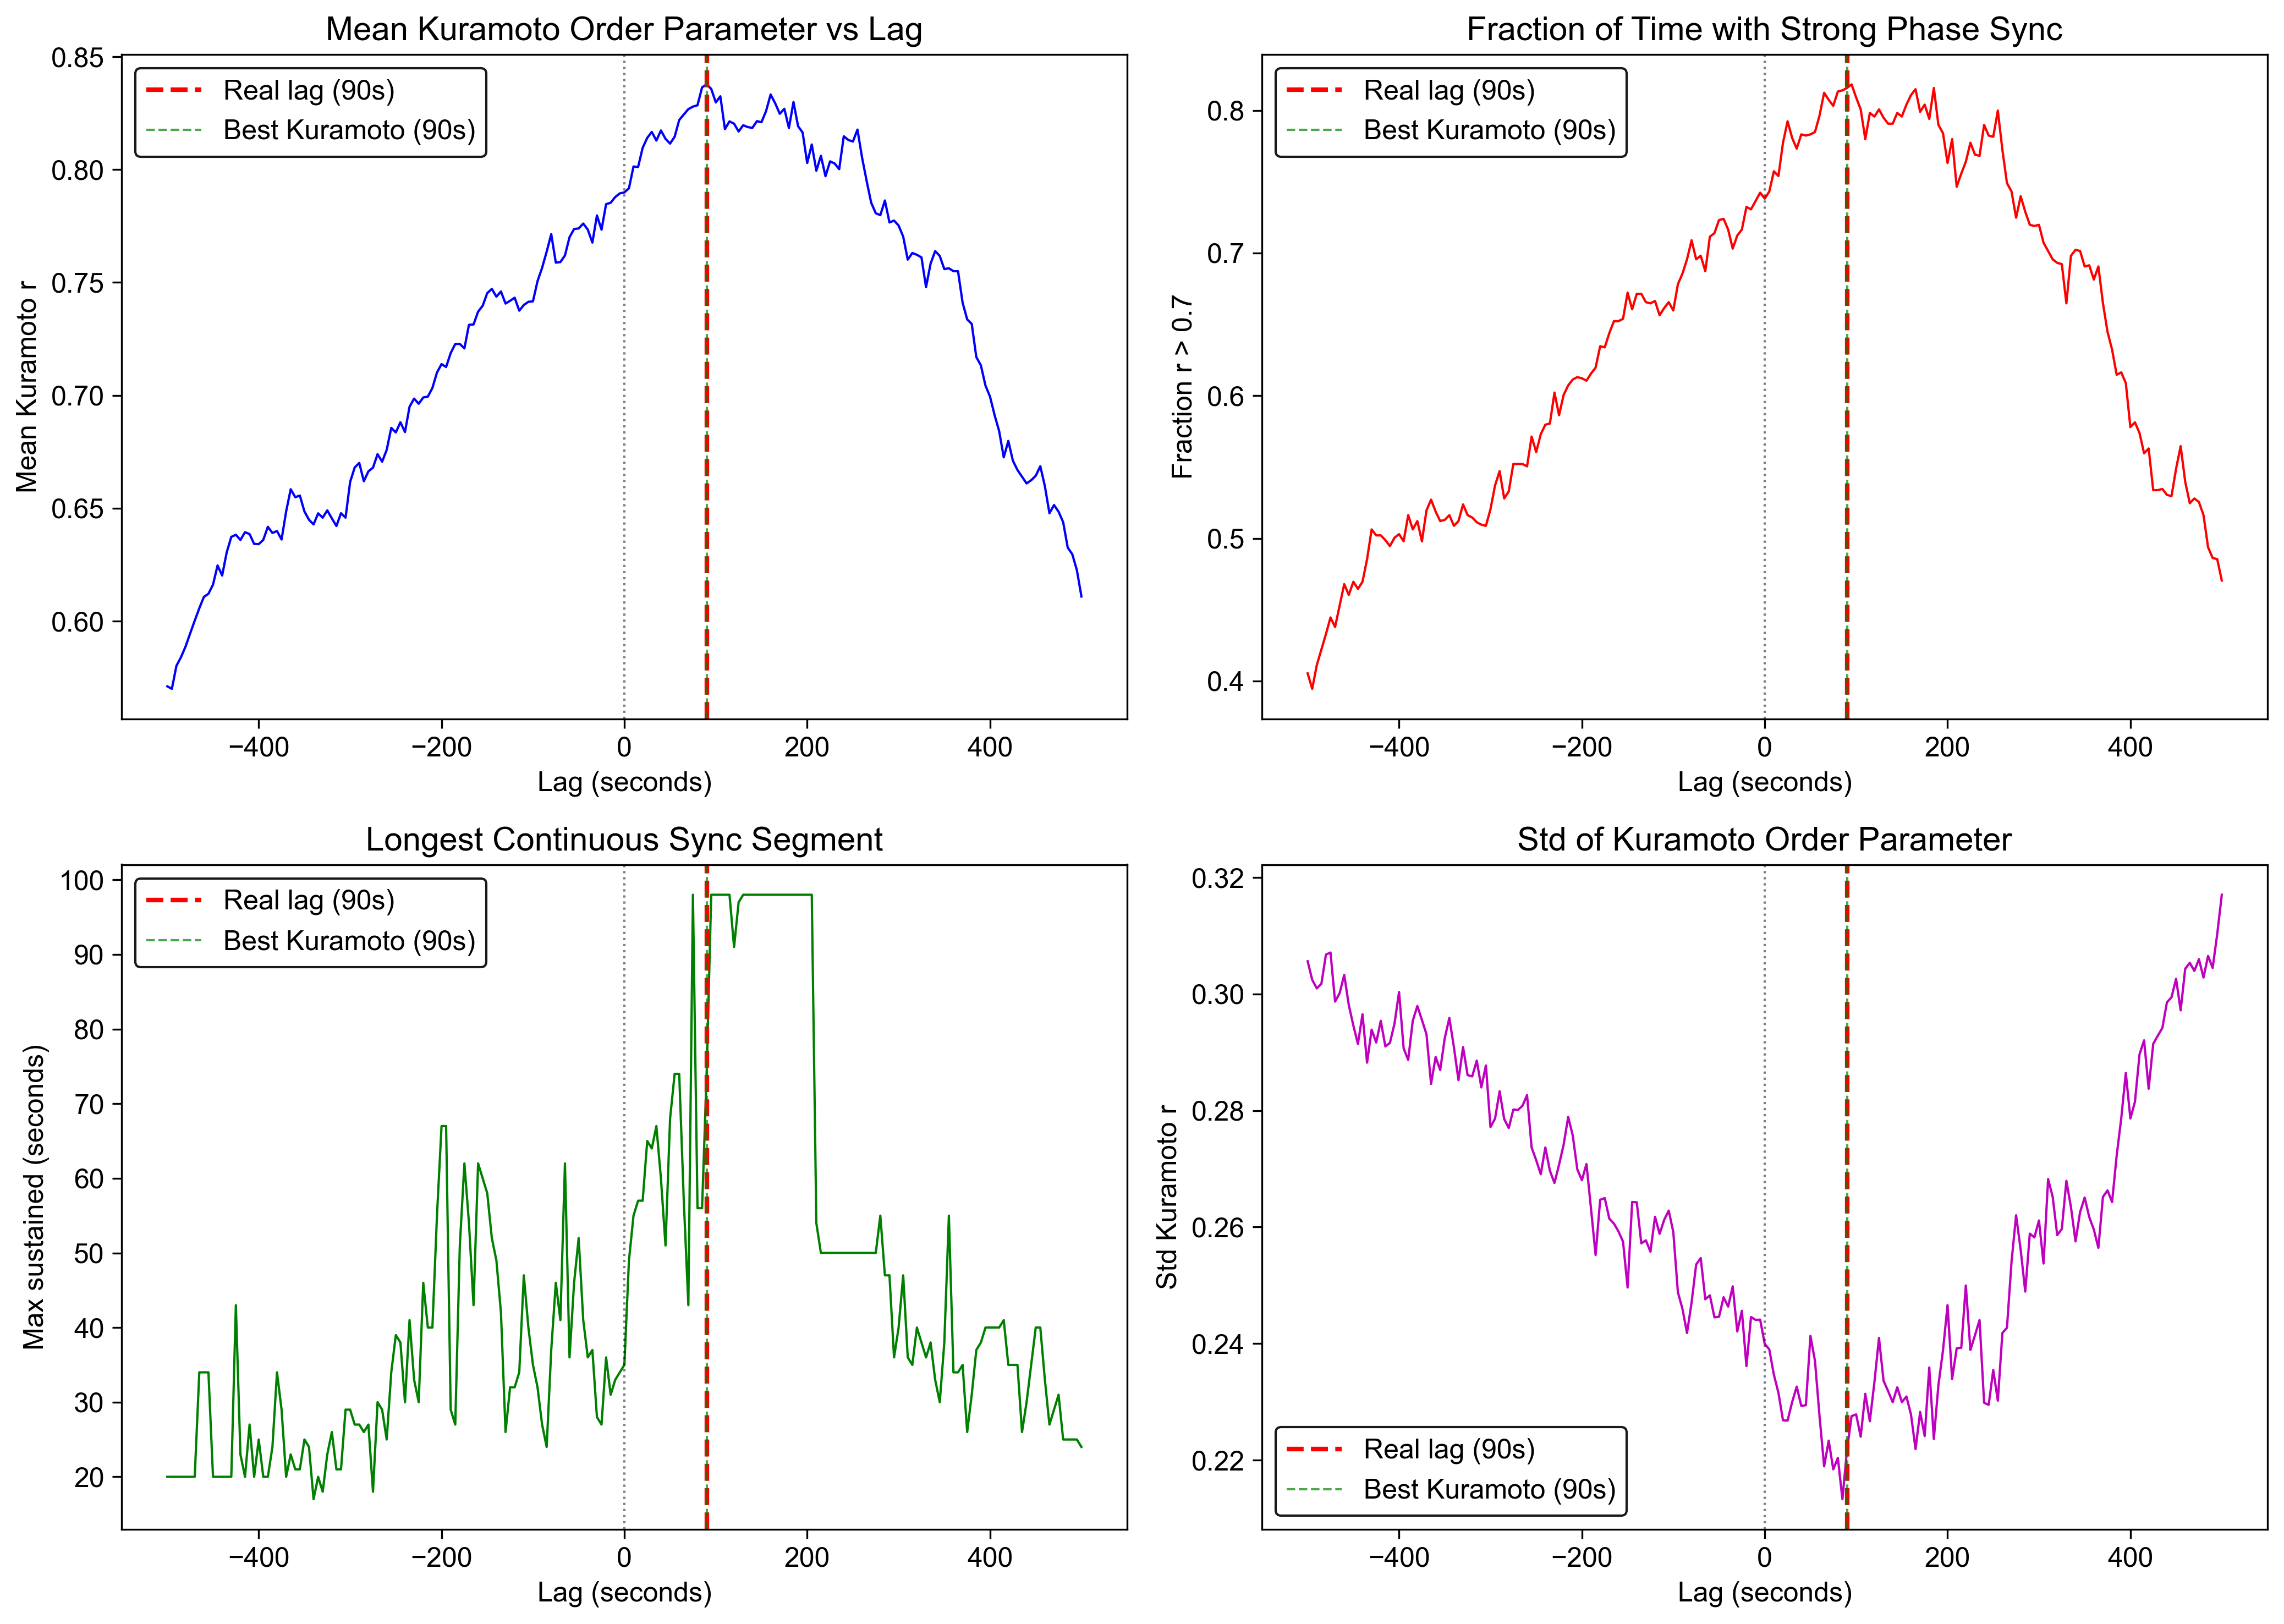

In [3]:
# Plot Kuramoto metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')

real_lag = 90  # seconds (1.5 min)

axes[0, 0].plot(results_df['lag'], results_df['r_mean'], 'b-', linewidth=1)
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Mean Kuramoto r')
axes[0, 0].set_title('Mean Kuramoto Order Parameter vs Lag')
axes[0, 0].grid(False)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[0, 0].axvline(x=best_kuramoto, color='g', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto}s)')
axes[0, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[0, 1].plot(results_df['lag'], results_df['frac_above_07'], 'r-', linewidth=1)
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Fraction r > 0.7')
axes[0, 1].set_title('Fraction of Time with Strong Phase Sync')
axes[0, 1].grid(False)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[0, 1].axvline(x=best_kuramoto, color='g', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto}s)')
axes[0, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 0].plot(results_df['lag'], results_df['max_sustained_sec'], 'g-', linewidth=1)
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Max sustained (seconds)')
axes[1, 0].set_title('Longest Continuous Sync Segment')
axes[1, 0].grid(False)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[1, 0].axvline(x=best_kuramoto, color='g', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto}s)')
axes[1, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 1].plot(results_df['lag'], results_df['r_std'], 'm-', linewidth=1)
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('Std Kuramoto r')
axes[1, 1].set_title('Std of Kuramoto Order Parameter')
axes[1, 1].grid(False)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[1, 1].axvline(x=best_kuramoto, color='g', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto}s)')
axes[1, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

plt.tight_layout()
plt.show()

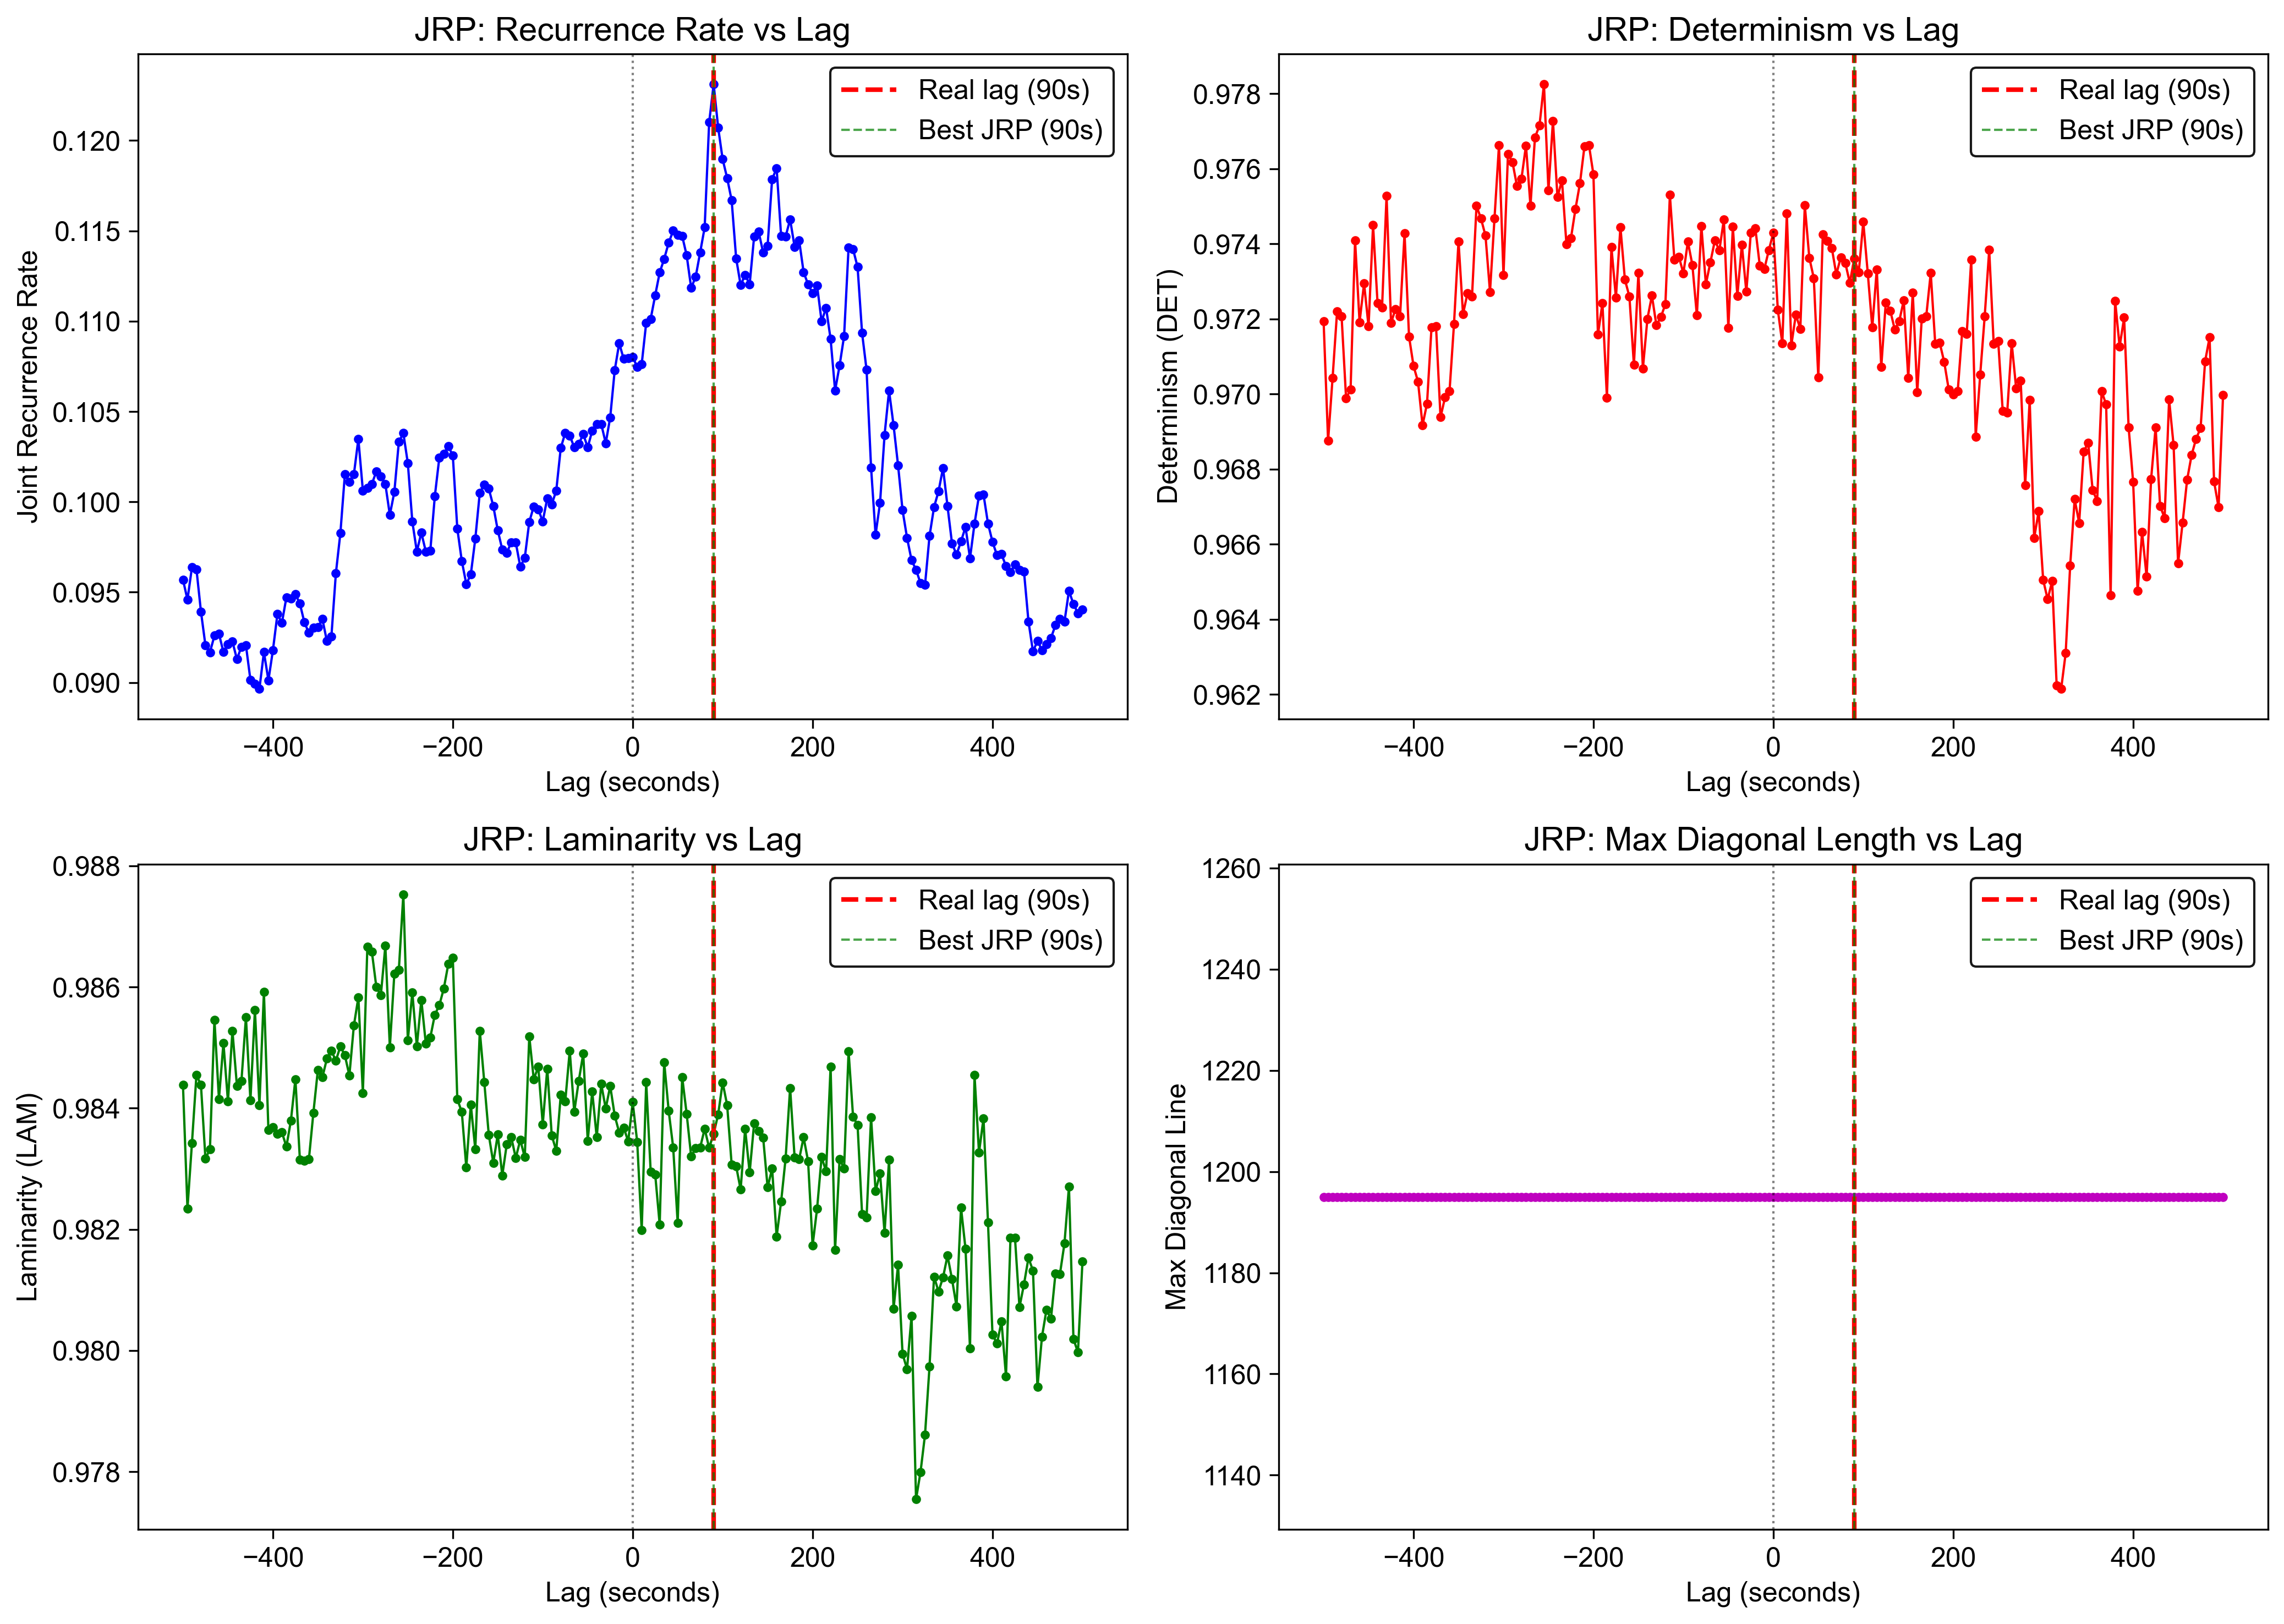

In [4]:
# Plot JRP metrics
jrp_df = results_df[results_df['jrp_RR'] > 0].copy()

real_lag = 90  # seconds (1.5 min)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')

axes[0, 0].plot(jrp_df['lag'], jrp_df['jrp_RR'], 'b-o', linewidth=1, markersize=3)
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Joint Recurrence Rate')
axes[0, 0].set_title('JRP: Recurrence Rate vs Lag')
axes[0, 0].grid(False)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
if best_jrp != 'N/A':
    axes[0, 0].axvline(x=best_jrp, color='g', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp}s)')
axes[0, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[0, 1].plot(jrp_df['lag'], jrp_df['jrp_DET'], 'r-o', linewidth=1, markersize=3)
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Determinism (DET)')
axes[0, 1].set_title('JRP: Determinism vs Lag')
axes[0, 1].grid(False)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
if best_jrp != 'N/A':
    axes[0, 1].axvline(x=best_jrp, color='g', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp}s)')
axes[0, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 0].plot(jrp_df['lag'], jrp_df['jrp_LAM'], 'g-o', linewidth=1, markersize=3)
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Laminarity (LAM)')
axes[1, 0].set_title('JRP: Laminarity vs Lag')
axes[1, 0].grid(False)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
if best_jrp != 'N/A':
    axes[1, 0].axvline(x=best_jrp, color='g', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp}s)')
axes[1, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 1].plot(jrp_df['lag'], jrp_df['jrp_max_diag'], 'm-o', linewidth=1, markersize=3)
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('Max Diagonal Line')
axes[1, 1].set_title('JRP: Max Diagonal Length vs Lag')
axes[1, 1].grid(False)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
if best_jrp != 'N/A':
    axes[1, 1].axvline(x=best_jrp, color='g', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp}s)')
axes[1, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

plt.tight_layout()
plt.show()

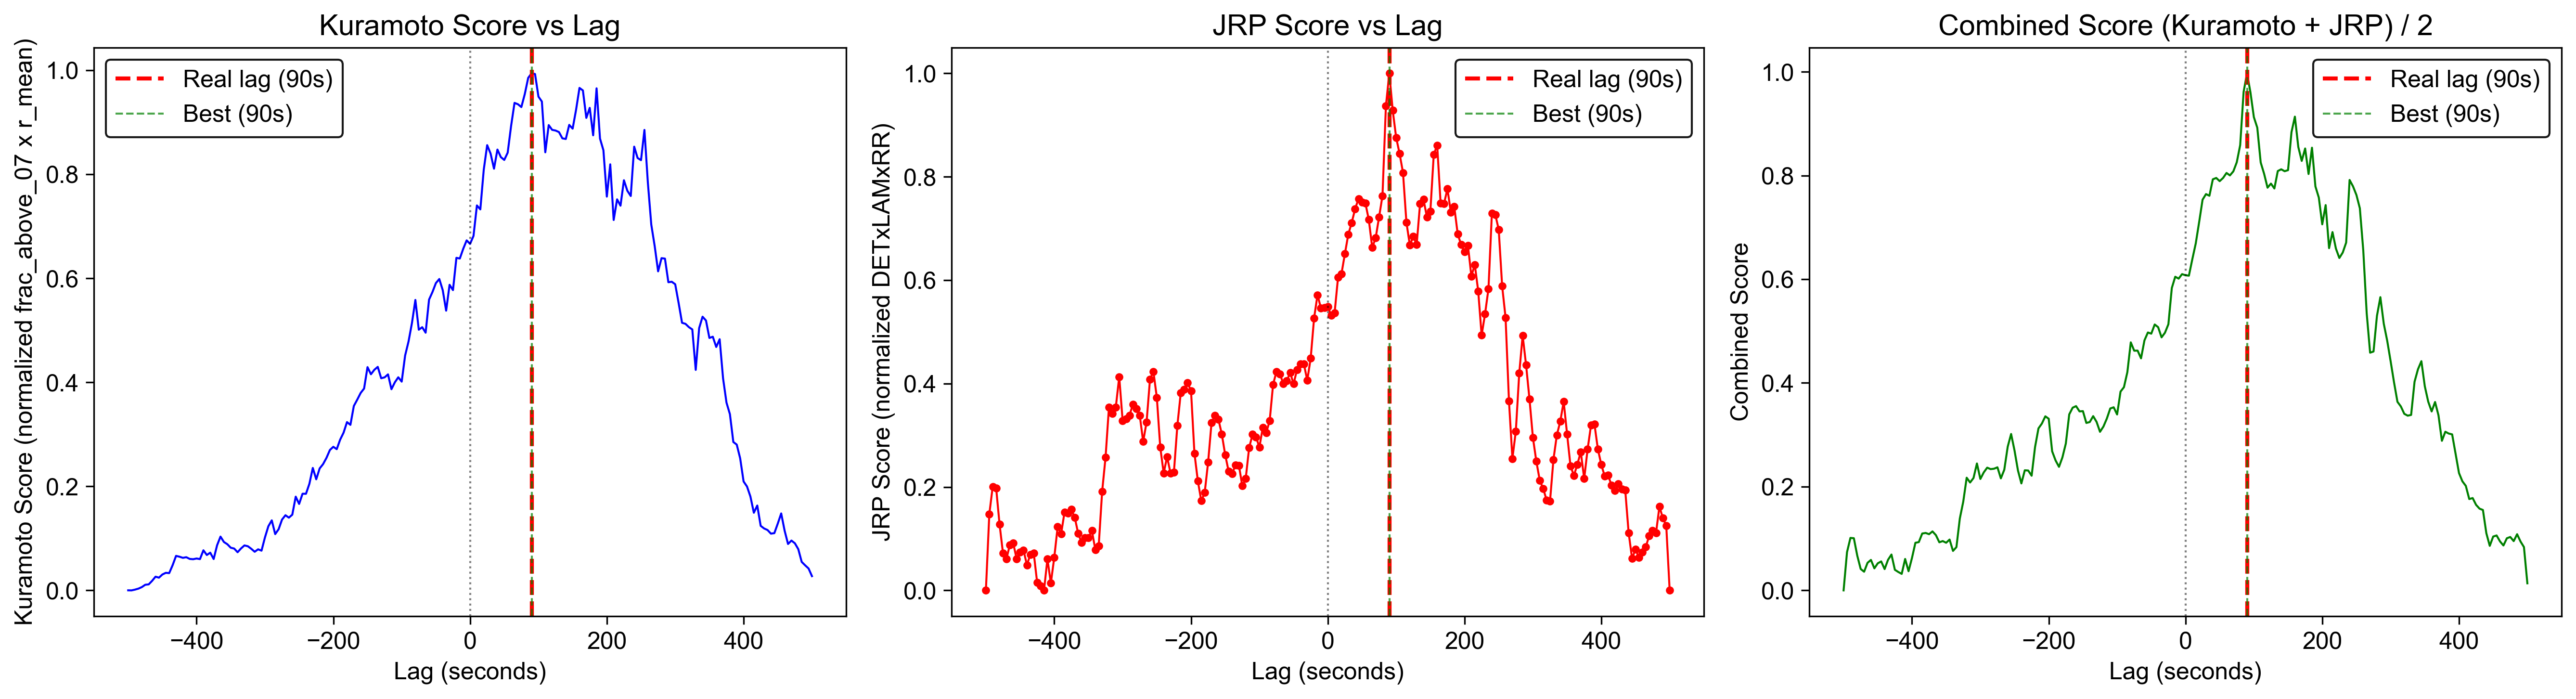

In [5]:
# Combined scores plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')

real_lag = 90  # seconds (1.5 min)

axes[0].plot(results_df['lag'], results_df['kuramoto_score'], 'b-', linewidth=1)
axes[0].set_xlabel('Lag (seconds)')
axes[0].set_ylabel('Kuramoto Score (normalized frac_above_07 x r_mean)')
axes[0].set_title('Kuramoto Score vs Lag')
axes[0].grid(False)
axes[0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[0].axvline(x=best_kuramoto, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_kuramoto}s)')
axes[0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1].plot(jrp_df['lag'], jrp_df['jrp_score'], 'r-o', linewidth=1, markersize=3)
axes[1].set_xlabel('Lag (seconds)')
axes[1].set_ylabel('JRP Score (normalized DETxLAMxRR)')
axes[1].set_title('JRP Score vs Lag')
axes[1].grid(False)
axes[1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
if best_jrp != 'N/A':
    axes[1].axvline(x=best_jrp, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_jrp}s)')
axes[1].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[2].plot(results_df['lag'], results_df['combined_score'], 'g-', linewidth=1)
axes[2].set_xlabel('Lag (seconds)')
axes[2].set_ylabel('Combined Score')
axes[2].set_title('Combined Score (Kuramoto + JRP) / 2')
axes[2].grid(False)
axes[2].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[2].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[2].axvline(x=best_combined, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_combined}s)')
axes[2].legend(frameon=True, framealpha=0.9, edgecolor="black")

plt.tight_layout()
plt.show()

In [6]:
# Top 10 results
print('=== Top 10 by Kuramoto Score (frac_above_07 × r_mean) ===')
print(results_df.nlargest(10, 'kuramoto_score')[['lag', 'r_mean', 'frac_above_07', 'max_sustained_sec', 'kuramoto_score']].to_string(index=False))

jrp_valid = results_df[(results_df['lag'] != -results_df['lag'].max()) & (results_df['lag'] != results_df['lag'].max()) & (results_df['jrp_RR'] > 0)].copy()
print('\n=== Top 10 by JRP Score (RR only, excl. extreme lags) ===')
print(jrp_valid.nlargest(10, 'jrp_score')[['lag', 'jrp_RR', 'jrp_DET', 'jrp_LAM', 'jrp_max_diag', 'jrp_score']].to_string(index=False))

print('\n=== Top 10 by Combined Score ===')
print(results_df.nlargest(10, 'combined_score')[['lag', 'r_mean', 'frac_above_07', 'max_sustained_sec', 'jrp_RR', 'jrp_DET', 'combined_score']].to_string(index=False))

=== Top 10 by Kuramoto Score (frac_above_07 × r_mean) ===
 lag   r_mean  frac_above_07  max_sustained_sec  kuramoto_score
  90 0.837718       0.815680                 74        0.994094
  95 0.835748       0.818182                 98        0.992641
  85 0.836399       0.814012                 56        0.985278
 160 0.833261       0.810676                 98        0.965930
 185 0.829927       0.815680                 98        0.965161
 165 0.829343       0.814846                 98        0.961086
  80 0.828491       0.813178                 56        0.954125
 100 0.829739       0.809008                 98        0.949184
 105 0.832445       0.800667                 98        0.939778
  65 0.824403       0.812344                 57        0.937165

=== Top 10 by JRP Score (RR only, excl. extreme lags) ===
 lag   jrp_RR  jrp_DET  jrp_LAM  jrp_max_diag  jrp_score
  90 0.123120 0.973609 0.983580          1195   1.000000
  85 0.121006 0.972963 0.983345          1195   0.936817
  95 0.1